In [88]:
import helpers
# from update_vars import analysis_date
from shared_utils import rt_dates
import geopandas as gpd
import pandas as pd

In [89]:
analysis_date = rt_dates.DATES['jun2026']

In [90]:
cols = [
        "gtfs_dataset_key",
        "feed_key",
        # "base64_url",
        "name",
        "trip_id",
        "shape_id",
        "shape_array_key",
        "route_id",
        "route_key",
        "direction_id",
        "route_short_name",
    ]

In [91]:
trips = helpers.import_scheduled_trips(analysis_date, columns=cols)

In [92]:
sd_trips = trips[trips.name == 'San Diego Schedule']
trips_225 = sd_trips[sd_trips.route_short_name == '225']

In [93]:
trips_225

,schedule_gtfs_dataset_key,feed_key,name,trip_id,shape_id,shape_array_key,route_id,route_key,direction_id,route_short_name
7870,7ee71e62eafbb6d39ad97e72f9cd0ac2,d30febfa1dceef95a92515eaeeaa3022,San Diego Schedule,19383674,S2_225_0_23,7367dd30911a89f6546117ca7b340328,225,e171daa6f38588507011bcddc22bcaab,0.0,225
7871,7ee71e62eafbb6d39ad97e72f9cd0ac2,d30febfa1dceef95a92515eaeeaa3022,San Diego Schedule,19383678,S2_225_0_23,7367dd30911a89f6546117ca7b340328,225,e171daa6f38588507011bcddc22bcaab,0.0,225
7872,7ee71e62eafbb6d39ad97e72f9cd0ac2,d30febfa1dceef95a92515eaeeaa3022,San Diego Schedule,19383651,S2_225_0_23,7367dd30911a89f6546117ca7b340328,225,e171daa6f38588507011bcddc22bcaab,0.0,225
7873,7ee71e62eafbb6d39ad97e72f9cd0ac2,d30febfa1dceef95a92515eaeeaa3022,San Diego Schedule,19383705,S2_225_0_23,7367dd30911a89f6546117ca7b340328,225,e171daa6f38588507011bcddc22bcaab,0.0,225
7874,7ee71e62eafbb6d39ad97e72f9cd0ac2,d30febfa1dceef95a92515eaeeaa3022,San Diego Schedule,19383642,S2_225_0_23,7367dd30911a89f6546117ca7b340328,225,e171daa6f38588507011bcddc22bcaab,0.0,225
...,...,...,...,...,...,...,...,...,...,...
15713,7ee71e62eafbb6d39ad97e72f9cd0ac2,d30febfa1dceef95a92515eaeeaa3022,San Diego Schedule,19383640,S2_225_1_22,b420ca0d97690a0472ae74f130a5b020,225,e171daa6f38588507011bcddc22bcaab,1.0,225
15714,7ee71e62eafbb6d39ad97e72f9cd0ac2,d30febfa1dceef95a92515eaeeaa3022,San Diego Schedule,19383677,S2_225_1_22,b420ca0d97690a0472ae74f130a5b020,225,e171daa6f38588507011bcddc22bcaab,1.0,225
15715,7ee71e62eafbb6d39ad97e72f9cd0ac2,d30febfa1dceef95a92515eaeeaa3022,San Diego Schedule,19383703,S2_225_1_22,b420ca0d97690a0472ae74f130a5b020,225,e171daa6f38588507011bcddc22bcaab,1.0,225
15716,7ee71e62eafbb6d39ad97e72f9cd0ac2,d30febfa1dceef95a92515eaeeaa3022,San Diego Schedule,19383637,S2_225_1_22,b420ca0d97690a0472ae74f130a5b020,225,e171daa6f38588507011bcddc22bcaab,1.0,225


In [94]:
shapes = helpers.import_scheduled_shapes(analysis_date)


In [123]:
shapes_225 = shapes[shapes.shape_array_key.isin(trips_225.shape_array_key.unique())]

In [124]:
shapes_225.crs

<Projected CRS: EPSG:3310>
Name: NAD83 / California Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - California.
- bounds: (-124.45, 32.53, -114.12, 42.01)
Coordinate Operation:
- name: California Albers
- method: Albers Equal Area
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [125]:
shapes_225.explore(column='shape_array_key')

placeholder

In [126]:
shapes_225 = shapes_225.assign(shape_length_meters = shapes_225.geometry.map(lambda x: x.length),
                               direction = shapes_225.shape_array_key.map(lambda x: 'SB' if x[-3:] == '020' else 'NB')).drop(columns=['geometry'])

In [127]:
st = helpers.import_scheduled_stop_times(analysis_date, filters=[['feed_key', '==', trips_225.feed_key.iloc[0]]],
                                            columns=['feed_key', 'trip_id', 'stop_id', 'stop_sequence', 'arrival_sec', 'departure_sec',
                                                      'arrival_hour', 'departure_hour'],
                                          get_pandas=True)

In [128]:
small_trips = trips_225[['route_id', 'shape_array_key', 'trip_id']].copy()

In [129]:
st.columns

Index(['feed_key', 'trip_id', 'stop_id', 'stop_sequence', 'arrival_sec',
       'departure_sec', 'arrival_hour', 'departure_hour'],
      dtype='object')

In [130]:
df = pd.merge(st, small_trips, on='trip_id')

In [131]:
df

,feed_key,trip_id,stop_id,stop_sequence,arrival_sec,departure_sec,arrival_hour,departure_hour,route_id,shape_array_key
0,d30febfa1dceef95a92515eaeeaa3022,19383627,88959,2,22680.0,22680.0,6.0,6.0,225,7367dd30911a89f6546117ca7b340328
1,d30febfa1dceef95a92515eaeeaa3022,19383641,13314,3,34860.0,34860.0,9.0,9.0,225,b420ca0d97690a0472ae74f130a5b020
2,d30febfa1dceef95a92515eaeeaa3022,19383645,88960,13,34920.0,34920.0,9.0,9.0,225,b420ca0d97690a0472ae74f130a5b020
3,d30febfa1dceef95a92515eaeeaa3022,19383653,99342,9,42060.0,42060.0,11.0,11.0,225,7367dd30911a89f6546117ca7b340328
4,d30febfa1dceef95a92515eaeeaa3022,19383657,88953,5,43920.0,43920.0,12.0,12.0,225,7367dd30911a89f6546117ca7b340328
...,...,...,...,...,...,...,...,...,...,...
1051,d30febfa1dceef95a92515eaeeaa3022,19383624,10487,6,23040.0,23040.0,6.0,6.0,225,b420ca0d97690a0472ae74f130a5b020
1052,d30febfa1dceef95a92515eaeeaa3022,19383651,88953,5,38400.0,38400.0,10.0,10.0,225,7367dd30911a89f6546117ca7b340328
1053,d30febfa1dceef95a92515eaeeaa3022,19383661,99589,2,47220.0,47220.0,13.0,13.0,225,b420ca0d97690a0472ae74f130a5b020
1054,d30febfa1dceef95a92515eaeeaa3022,19383677,88950,8,59700.0,59700.0,16.0,16.0,225,b420ca0d97690a0472ae74f130a5b020


In [132]:
trip_durations = (df.groupby(['feed_key', 'trip_id', 'route_id', 'shape_array_key'])
 .agg({'departure_sec': 'min', 'arrival_sec': 'max', 'departure_hour': 'median'})
 .rename(columns={'departure_sec': 'trip_start', 'arrival_sec': 'trip_end', 'departure_hour': 'median_hour'})
 .reset_index()
 )

In [133]:
trip_durations = trip_durations.assign(duration_sec = trip_durations.trip_end - trip_durations.trip_start)

In [134]:
trip_durations = trip_durations.merge(shapes_225, on='shape_array_key')

In [135]:
trip_durations = trip_durations.assign(trip_speed_meters_sec = trip_durations.shape_length_meters / trip_durations.duration_sec)
trip_durations = trip_durations.assign(trip_speed_mph = trip_durations.trip_speed_meters_sec * 3600 / 1609)

In [137]:
trip_durations

,feed_key,trip_id,route_id,shape_array_key,trip_start,trip_end,median_hour,duration_sec,shape_length_meters,direction,trip_speed_meters_sec,trip_speed_mph
0,d30febfa1dceef95a92515eaeeaa3022,19383620,225,7367dd30911a89f6546117ca7b340328,15780.0,19260.0,4.0,3480.0,39734.219271,NB,11.417879,25.546529
1,d30febfa1dceef95a92515eaeeaa3022,19383621,225,7367dd30911a89f6546117ca7b340328,16980.0,20460.0,5.0,3480.0,39734.219271,NB,11.417879,25.546529
2,d30febfa1dceef95a92515eaeeaa3022,19383622,225,7367dd30911a89f6546117ca7b340328,18360.0,22020.0,5.0,3660.0,39734.219271,NB,10.856344,24.290142
3,d30febfa1dceef95a92515eaeeaa3022,19383623,225,7367dd30911a89f6546117ca7b340328,19560.0,23280.0,5.0,3720.0,39734.219271,NB,10.681242,23.898366
4,d30febfa1dceef95a92515eaeeaa3022,19383624,225,b420ca0d97690a0472ae74f130a5b020,22560.0,26100.0,6.0,3540.0,39961.556540,SB,11.288575,25.257223
...,...,...,...,...,...,...,...,...,...,...,...,...
83,d30febfa1dceef95a92515eaeeaa3022,19383703,225,b420ca0d97690a0472ae74f130a5b020,78000.0,81540.0,22.0,3540.0,39961.556540,SB,11.288575,25.257223
84,d30febfa1dceef95a92515eaeeaa3022,19383704,225,7367dd30911a89f6546117ca7b340328,78540.0,81960.0,22.0,3420.0,39734.219271,NB,11.618193,25.994713
85,d30febfa1dceef95a92515eaeeaa3022,19383705,225,7367dd30911a89f6546117ca7b340328,76740.0,80160.0,21.0,3420.0,39734.219271,NB,11.618193,25.994713
86,d30febfa1dceef95a92515eaeeaa3022,19383706,225,b420ca0d97690a0472ae74f130a5b020,81600.0,85140.0,23.0,3540.0,39961.556540,SB,11.288575,25.257223


<Axes: >

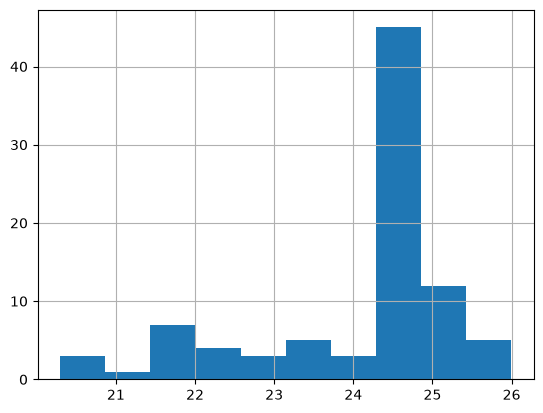

In [ ]:
trip_durations.trip_speed_mph.hist()

<Axes: xlabel='median_hour', ylabel='trip_speed_mph'>

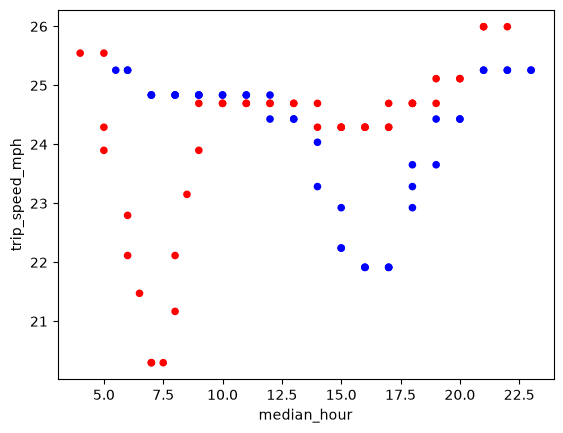

In [148]:
trip_durations = trip_durations.assign(color=trip_durations.direction.map(lambda x: 'red' if x == 'NB' else 'blue'))
trip_durations.plot.scatter(x='median_hour', y='trip_speed_mph', c='color')

NB in red, SB in blue

In [141]:
trip_durations = trip_durations.sort_values(by=['shape_array_key', 'median_hour']).assign(analysis_date = analysis_date)

In [142]:
trip_durations.to_csv(f'sdmts_225_durations_{analysis_date}.csv')